# Задание по практике

Необходимо на примере практической задачи  изучить библиотеки языка Python.

Ссылка на датасет: [*тык*](https://www.kaggle.com/datasets/prince7489/youtube-shorts-performance-dataset)

# Используемые библиотеки

Для выполнения анализа данных и построения моделей в работе используются следующие библиотеки языка Python:

- **NumPy (`numpy`)** — библиотека для выполнения математических вычислений и работы с многомерными массивами. Используется для обработки числовых данных и выполнения различных вычислительных операций.

- **Pandas (`pandas`)** — библиотека для работы с табличными данными. Позволяет загружать, обрабатывать, фильтровать и анализировать данные, представленные в формате DataFrame.

- **SciPy (`scipy.stats`)** — модуль библиотеки SciPy, содержащий инструменты математической статистики. Используется для расчета статистических показателей и проведения статистических тестов.

- **Seaborn (`seaborn`)** — библиотека для визуализации данных, построенная на основе Matplotlib. Применяется для создания информативных статистических графиков и анализа распределений признаков.

- **Matplotlib (`matplotlib.pyplot`)** — библиотека для построения двумерных графиков и диаграмм. Используется для визуализации результатов анализа и представления полученных данных.

In [1]:
import numpy as np
import pandas as pd
import sklearn 

from scipy import stats 


import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# зададим параметры рисуемых нами графиков, например, размер
plt.rcParams['figure.figsize'] = (15, 12)

# Описание датасета


Этот набор данных содержит средние показатели эффективности YouTube Shorts, включающие 300 видео из различных категорий, таких как технологии, путешествия, еда, юмор, лайфстайл и образование.

Он включает подробные метрики вовлечённости и структуры контента, а также параметры публикации, что позволяет анализировать эффективность коротких видео и поведение аудитории.

Датасет подходит для разведочного анализа данных (EDA), визуализации, машинного обучения, анализа социальных сетей, оптимизации контент-стратегии и образовательных проектов.

---

## Признаки (описание переменных)

| Признак | Описание |
|----------|-------------|
| `duration_seconds` | Длительность видео в секундах |
| `hashtag_count` | Количество хэштегов в видео |
| `views` | Общее количество просмотров |
| `likes` | Количество лайков |
| `comments` | Количество комментариев |
| `shares` | Количество репостов |
| `upload_hour` | Час публикации видео |
| `category` | Категория контента (Tech, Travel, Food, Comedy, Lifestyle, Education) |

In [3]:
df = pd.read_csv('youtube_shorts_performance_dataset.csv')
df.head()

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


# Предварительныя обработка

## Информация о содержимом

На основную информацию по колнкам можно посмотреть с помощью метода `.info()`. Напротив каждого названия столбца можно увидеть, сколько в нём заполненных ячеек.

In [4]:
# информация о нашей табличке
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        300 non-null    object
 1   title           300 non-null    object
 2   duration_sec    300 non-null    int64 
 3   hashtags_count  300 non-null    int64 
 4   views           300 non-null    int64 
 5   likes           300 non-null    int64 
 6   comments        300 non-null    int64 
 7   shares          300 non-null    int64 
 8   upload_hour     300 non-null    int64 
 9   category        300 non-null    object
dtypes: int64(7), object(3)
memory usage: 23.6+ KB


Выделим какие у нас столцы численные, а какие категориальные 

In [5]:
num_data = [i for i in df.columns.values if df[i].dtype == 'int64']
cat_data = ['category']

В `pandas` по данным можно считать абсолютно все описательные статистики

In [6]:
df.describe()

,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,31.730000,4.343333,245058.166667,23063.126667,2638.296667,999.576667,11.543333
std,16.042912,2.956562,141338.982093,14597.458220,1416.827287,564.410105,6.814414
min,5.000000,0.000000,1404.000000,109.000000,40.000000,2.000000,0.000000
25%,18.000000,2.000000,129620.500000,10342.000000,1445.750000,516.250000,6.000000
50%,32.000000,4.000000,255962.000000,21779.500000,2863.500000,988.000000,12.000000
75%,45.000000,7.000000,356805.000000,36706.500000,3761.000000,1463.750000,17.000000
max,59.000000,9.000000,499401.000000,49923.000000,4971.000000,1998.000000,23.000000


Для каждой переменной мы видим: 

* `count` — число наблюдений, которое есть без пропусков
* `mean` — среднее значение
* `std` — стандартное отклонение
* `min` —  минимум
* `max` —  максимум
* `50%` —  медиана (половина выборки больше неё, половина меньше)
* `25%` —  25% квантиль (четверть выборки меньше, 75% больше)
* `75%` —  75% квантиль

In [7]:
colnames = df.dtypes[df.dtypes == 'int64'].index.values
df[colnames].corr(method='pearson')

,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour
duration_sec,1.000000,-0.035128,0.074487,-0.052211,0.078740,0.071623,0.002692
hashtags_count,-0.035128,1.000000,0.010908,0.011884,-0.042305,0.078601,0.034368
views,0.074487,0.010908,1.000000,0.035115,0.069525,0.015937,0.018833
likes,-0.052211,0.011884,0.035115,1.000000,-0.034672,-0.037390,-0.014855
comments,0.078740,-0.042305,0.069525,-0.034672,1.000000,-0.001715,0.016920
shares,0.071623,0.078601,0.015937,-0.037390,-0.001715,1.000000,-0.027530
upload_hour,0.002692,0.034368,0.018833,-0.014855,0.016920,-0.027530,1.000000


Пропуски в данных возникают по разным причинам. Кто-то забыл измерить, записать или в принципе таких данных в природе не существовало. Когда мы будем учить алгоритмы машинного обучения, нам придётся все эти пропуски заполнять. 

Проверить клетку таблицы на пропуск помогает метод `.isnull()`

Cуммарное количество пропусков в каждом столбце:

In [8]:
df.isnull().sum() 

video_id          0
title             0
duration_sec      0
hashtags_count    0
views             0
likes             0
comments          0
shares            0
upload_hour       0
category          0
dtype: int64

# Визуализация

### Графики распределения численных признаков

Функция предназначена для визуального анализа числовых признаков набора данных. Для каждого столбца из списка `num_data` строится гистограмма распределения с наложенной кривой ядерной оценки плотности (KDE), что позволяет оценить форму распределения, наличие асимметрии, выбросов и многомодальности.

#### Параметры
- **`df`** — объект `pandas.DataFrame`, содержащий данные.
- **`num_data`** — список названий числовых столбцов, для которых необходимо построить графики.

#### Что делает функция
- Автоматически определяет необходимое количество строк подграфиков, размещая по **3 графика в строке**.
- Для каждого числового признака строит:
  - гистограмму распределения;
  - кривую KDE (Kernel Density Estimation).
- В заголовке каждого графика отображает основные статистические характеристики признака:
  - среднее значение (Mean);
  - медиану (Median);
  - стандартное отклонение (Std).
- Подписывает оси:
  - **X** — название признака;
  - **Y** — количество наблюдений (Count).
- Если количество признаков не кратно трём, автоматически удаляет пустые области с графиками.
- Использует `plt.tight_layout()` для корректного расположения элементов и отображает результат с помощью `plt.show()`.

In [9]:
def num_plot(df, num_data):
    n = len(num_data)
    rows = n // 3 + (n % 3 > 0)

    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_data):
        sns.histplot(df[col], kde=True, bins=30, ax=axes[i])

        axes[i].set_title(
            f"{col}\nMean: {df[col].mean():.2f} | Median: {df[col].median():.2f} | Std: {df[col].std():.2f}",
            fontsize=10
        )
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")

    # убрать пустые графики
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Вызываем нашу функцию

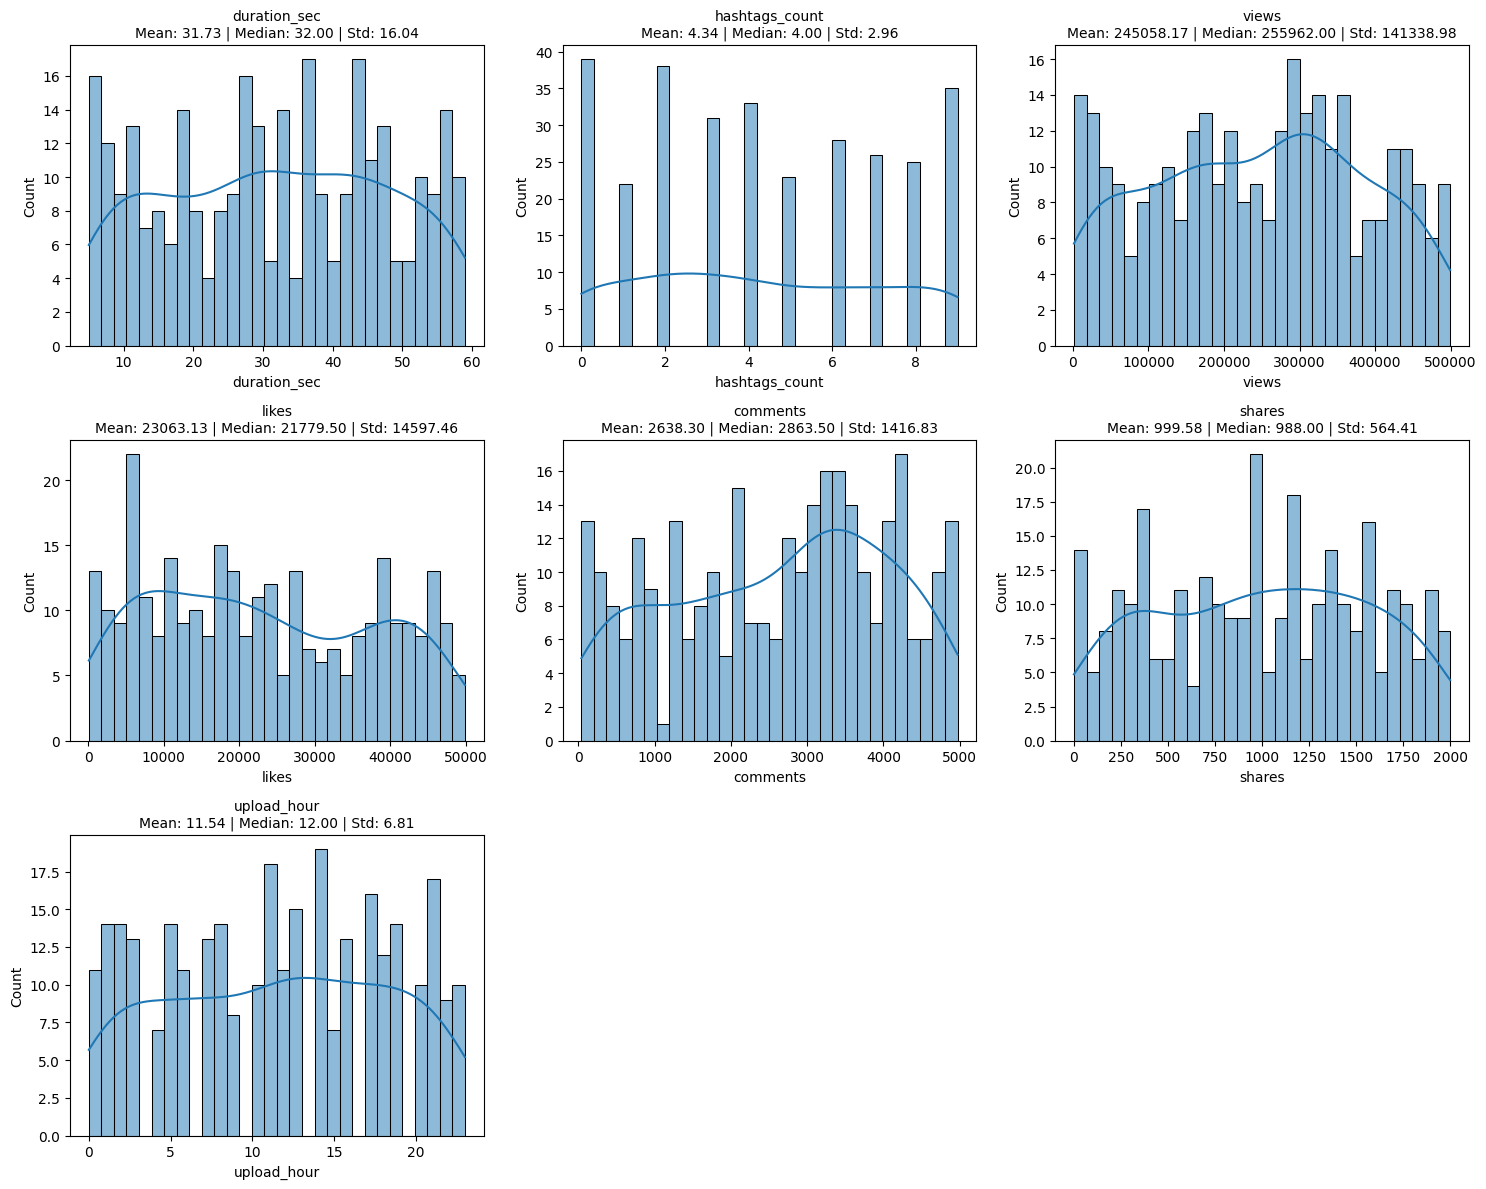

In [10]:
num_plot(df, num_data)

По всем графикам видно, что распределения неявные, скорее равномерные

Распределения в большей части многомодальны

По графику часа выгрузки видно, что пик активности приходится примерно на 16 вечера

### График бокс-плот для каждой численной переменной

Функция предназначена для визуального анализа числовых признаков с помощью диаграмм размаха (Box Plot). Такие графики позволяют оценить распределение данных, медиану, межквартильный размах, а также выявить возможные выбросы.

#### Параметры
- **`df`** — объект `pandas.DataFrame`, содержащий данные.
- **`num_data`** — список названий числовых столбцов, для которых необходимо построить диаграммы размаха.

#### Что делает функция
- Автоматически определяет необходимое количество строк подграфиков, размещая по **3 графика в строке**.
- Для каждого числового признака строит диаграмму размаха (Box Plot).
- В заголовке каждого графика отображает название соответствующего признака.
- Если количество признаков не кратно трём, автоматически удаляет пустые области с графиками.
- Использует `plt.tight_layout()` для корректного расположения всех элементов и отображает итоговую визуализацию с помощью `plt.show()`.


In [11]:
def boxplot_num_data(df, num_data):
    n = len(num_data)
    rows = n // 3 + (n % 3 > 0)

    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_data):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f"Boxplot of {col}")

    # удалить пустые графики
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Вызываем нашу функцию

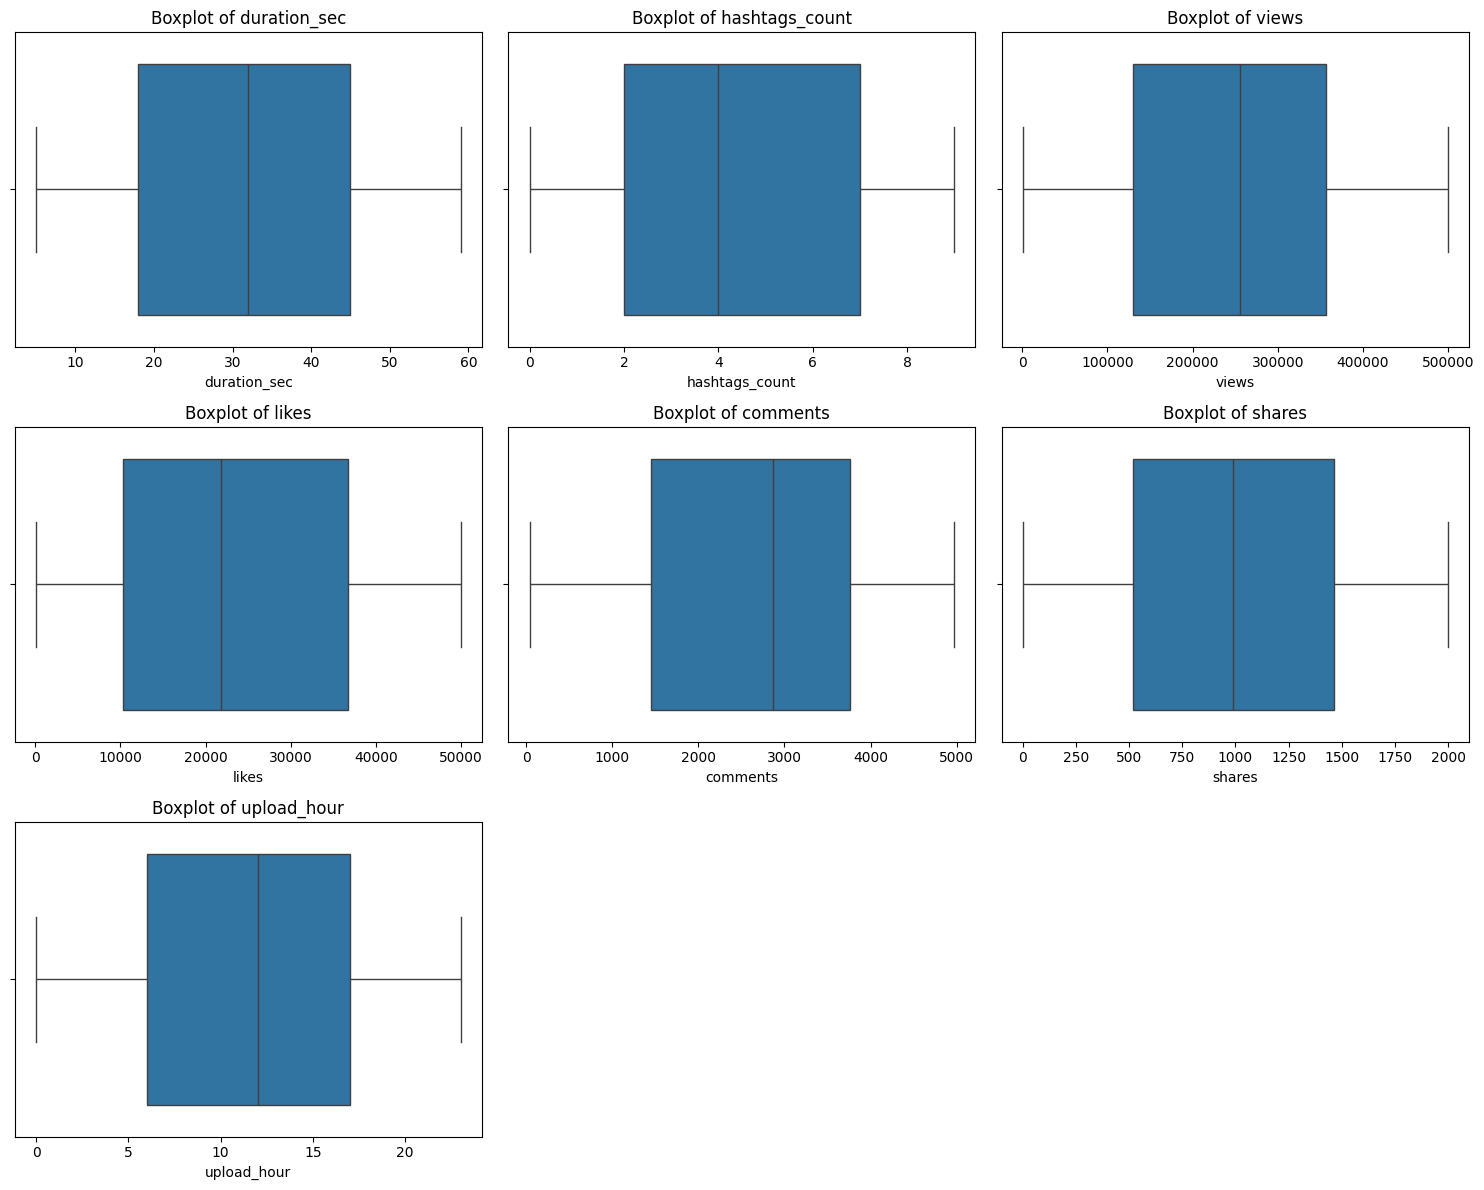

In [12]:
boxplot_num_data(df, num_data);



Анализ boxplot’ов ключевых переменных позволил выявить следующие важные закономерности:

Все показатели вовлеченности демонстрируют **сильное правое смещение** и большое количество выбросов в верхней части распределения. Это типичная картина для социальных сетей: большинство видео набирают относительно скромные охваты, в то время как небольшая доля контента становится значительно более популярной. Особенно ярко это выражено в количестве репостов (`shares`).

- Длительность видео относительно стабильна: большинство роликов укладывается в диапазон **20–45 секунд**.
- Количество хэштегов чаще всего находится в интервале **2–6**, с медианой 4. Распределение имеет несколько мод (пиков популярности).


Публикации сильно сконцентрированы в **дневное время** (медиана — 12:00). Пик активности приходится на интервал 10–16 часов. Ночное и раннее утреннее время используется значительно реже.


### Графики бокс-плот для численных признаков с разбиением по категориям

Функция `cat_boxplot` предназначена для визуализации распределения нескольких числовых переменных в разрезе одной категориальной переменной с помощью **ящичных диаграмм (boxplot)**.

#### Параметры

- `data` — pandas DataFrame с исходными данными.
- `num_data` — список названий числовых столбцов для анализа.
- `cat_col` — название категориальной колонки (по умолчанию `'category'`).

#### Логика работы

Функция автоматически определяет оптимальное количество строк для сетки графиков (3 столбца), строит boxplot для каждой числовой переменной с группировкой по категориальной переменной, добавляет заголовки, поворачивает метки осей и удаляет пустые подграфики.


In [13]:
def cat_boxplot(data, num_data, cat_col='category'):
    n = len(num_data)
    rows = n // 3 + (n % 3 > 0)

    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_data):
        sns.boxplot(x=data[cat_col], y=data[col], ax=axes[i], hue=data[cat_col])

        axes[i].set_title(f"{cat_col} vs {col}")
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel(col)

    # удалить пустые subplot
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Вызываем нашу функцию

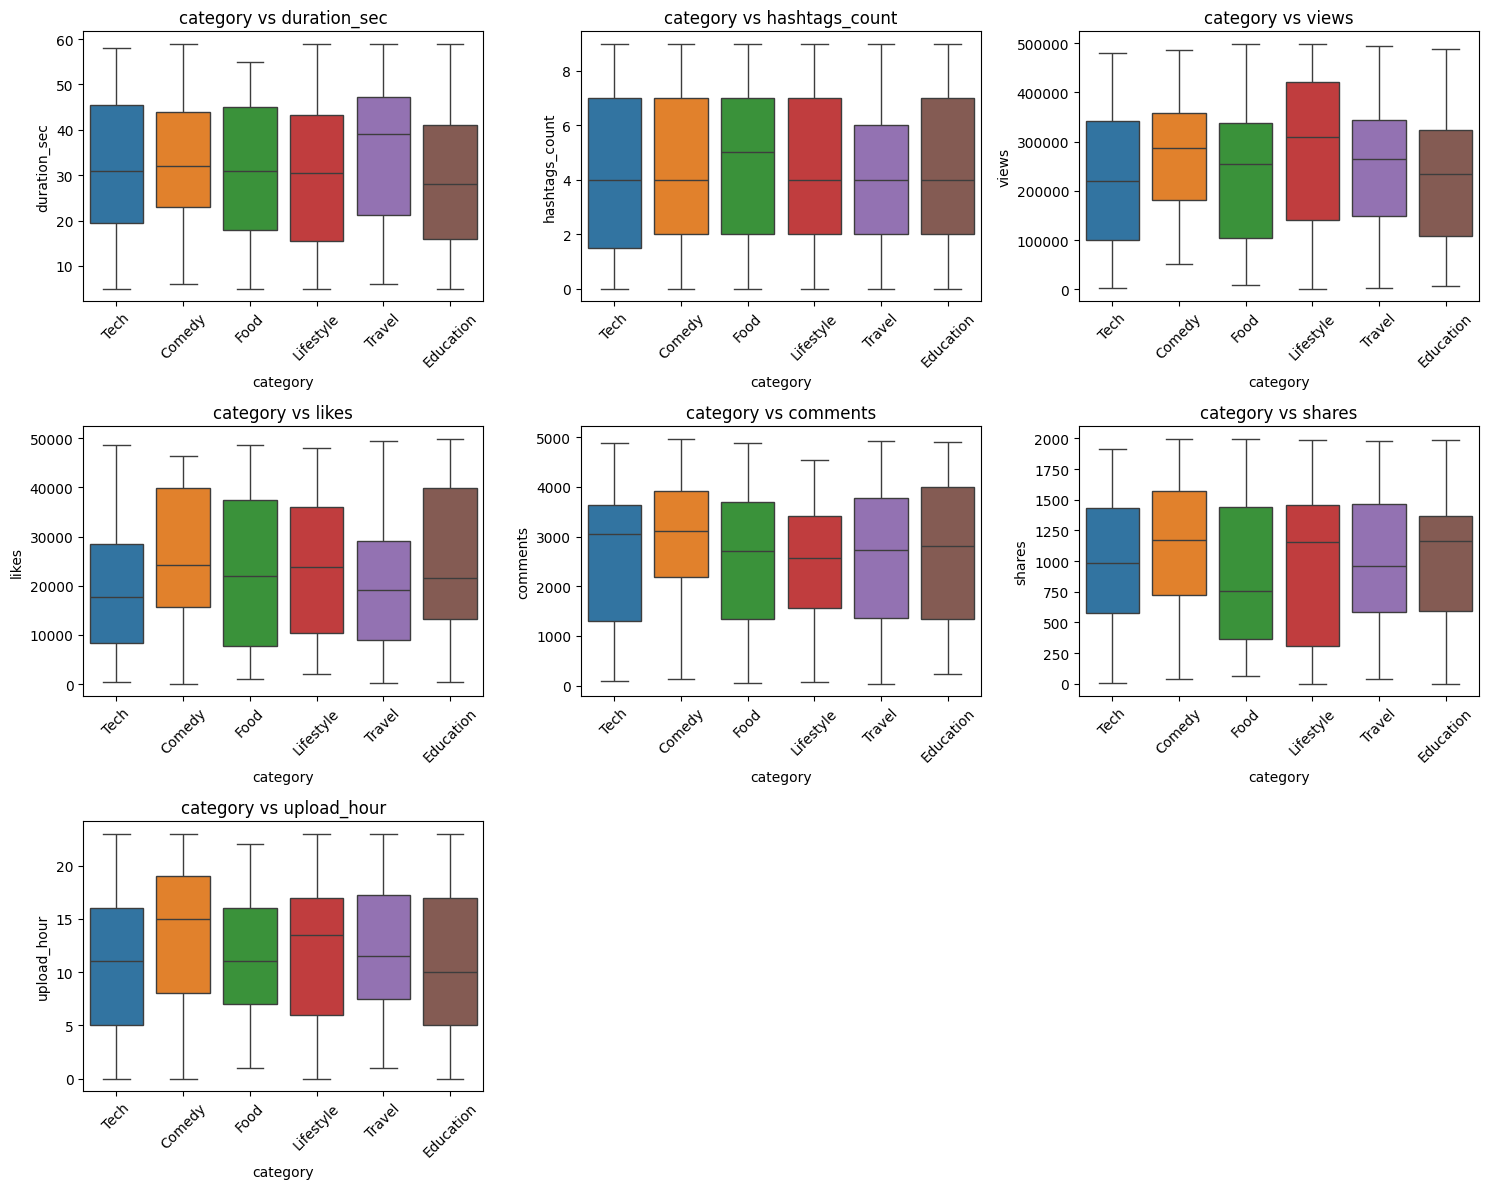

In [14]:
cat_boxplot(df, num_data);

Анализ boxplot’ов по категориям позволил выявить значимые различия в поведении и эффективности разных типов контента.

- **Наиболее успешные категории** — **Comedy** и **Lifestyle**. Они лидируют по количеству просмотров, лайков и репостов. Comedy также вызывает наибольшую вовлеченность в комментариях.
- **Категория Tech** демонстрирует самые слабые результаты почти по всем метрикам вовлеченности (просмотры, лайки, репосты), несмотря на активное использование хэштегов.
- **Education** и **Travel** показывают средние и выше среднего результаты, особенно по комментариям и репостам, что говорит о высоком потенциале этих направлений.
- **Food** занимает промежуточное положение, хорошо выступая по лайкам, но слабее по репостам.

Дополнительные особенности

- Разные категории предпочитают разную **длительность видео**: Travel и Education тяготеют к более длинным роликам, а Tech и Comedy — к коротким.
- Время публикации также отличается: Comedy чаще выходит вечером, в то время как Tech и Food — преимущественно в первой половине дня.


### Визуализация среднего количества просмотров по часам публикации

Данный код строит **линейный график**, показывающий, как меняется среднее количество просмотров в зависимости от часа суток, в который было загружено видео.

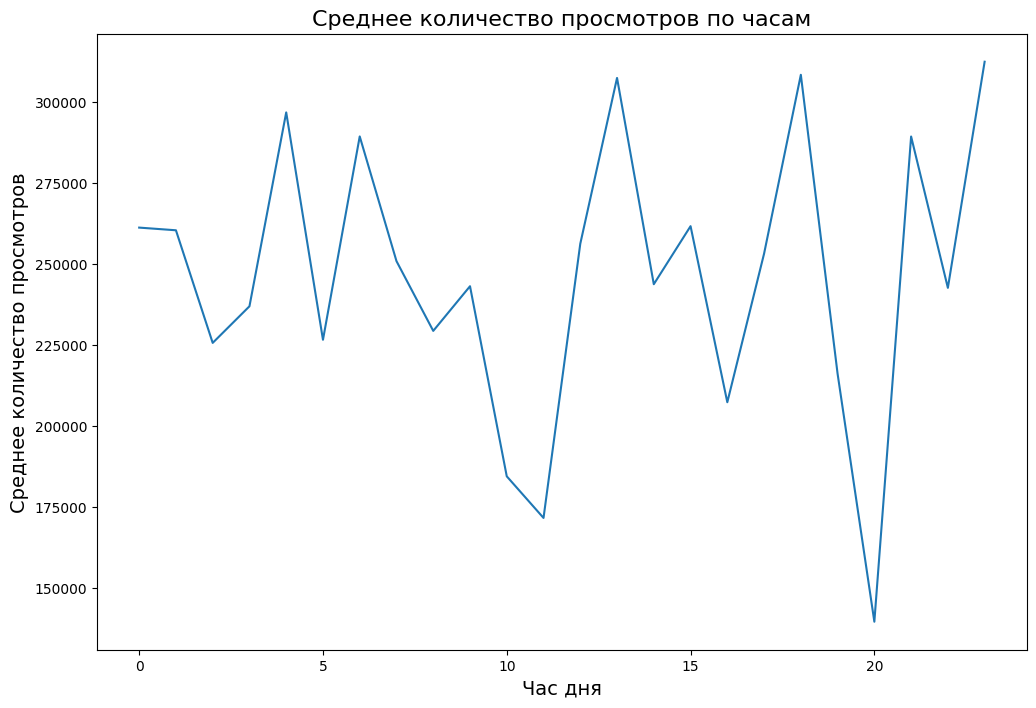

In [15]:
hourly_views = df.groupby('upload_hour')['views'].mean()
plt.figure(figsize=(12,8))
hourly_views.plot(kind='line')
plt.title('Среднее количество просмотров по часам', fontsize=16)
plt.xlabel('Час дня', fontsize=14)
plt.ylabel('Среднее количество просмотров', fontsize=14)
plt.show()

График демонстрирует заметную зависимость среднего количества просмотров от времени публикации видео. Наибольший охват наблюдается в районе 13–14 часов дня, а также в позднее вечернее и ночное время (после 22:00). 

В то же время наименьшее среднее количество просмотров характерно для периода 20–21 часа, а также для утренних часов (9–11). График имеет ярко выраженный волнообразный характер с несколькими выраженными пиками и спадами в течение суток.


Созданим новый признак отвечающий за определение того, что наше видео было выложено в дневное время

In [16]:
df['isDayTimeVideo'] = (df['upload_hour'] >= 12) & (df['upload_hour'] <= 18)
df

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category,isDayTimeVideo
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech,False
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy,True
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food,False
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle,False
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech,False
...,...,...,...,...,...,...,...,...,...,...,...
295,vid_1295,Short Video #295,15,3,248940,23810,488,1247,12,Tech,True
296,vid_1296,Short Video #296,32,4,366340,29586,46,1548,8,Travel,False
297,vid_1297,Short Video #297,29,3,434027,6471,3359,1069,21,Comedy,False
298,vid_1298,Short Video #298,54,4,318623,6459,4873,1690,14,Food,True


### Скрипичный график (Violin Plot) распределения лайков

Данный код строит **скрипичный график** для сравнения распределения количества лайков по категориям видео с разделением по времени публикации (день/ночь).

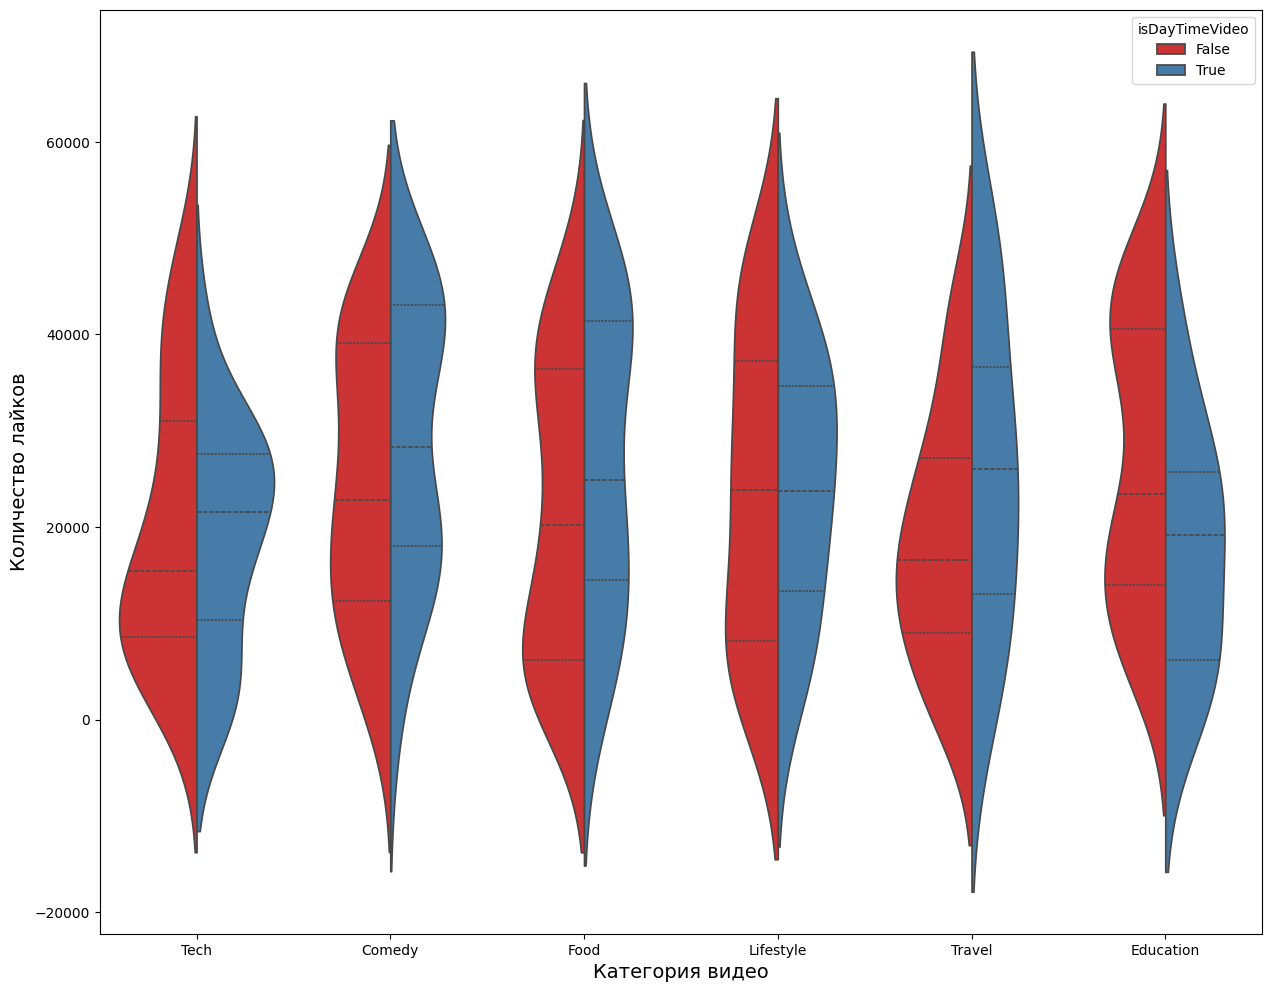

In [17]:
sns.violinplot(x='category', 
               y='likes', 
               hue='isDayTimeVideo',
               data=df, 
               split=True, 
               palette='Set1', 
               inner='quartile')

plt.xlabel('Категория видео',fontsize=14)
plt.ylabel('Количество лайков',fontsize=14);



Скрипичный график (violin plot) позволяет одновременно оценить форму распределения, медиану и сравнить дневные и ночные видео внутри каждой категории.

- Во всех категориях наблюдается **большой разброс** количества лайков, что подтверждается широкими "скрипками".
- В большинстве категорий **дневные видео** (синий цвет) показывают чуть более высокие медианные значения лайков по сравнению с ночными (красный цвет).
- Наиболее высокие медианные значения лайков наблюдаются в категориях **Comedy**, **Food** и **Lifestyle**.
- Категория **Tech** имеет один из самых низких уровней лайков среди всех категорий.
- Распределения имеют ярко выраженный правый хвост (особенно заметно в Comedy и Travel), что говорит о наличии отдельных очень успешных видео.


## График распределения категориального признака

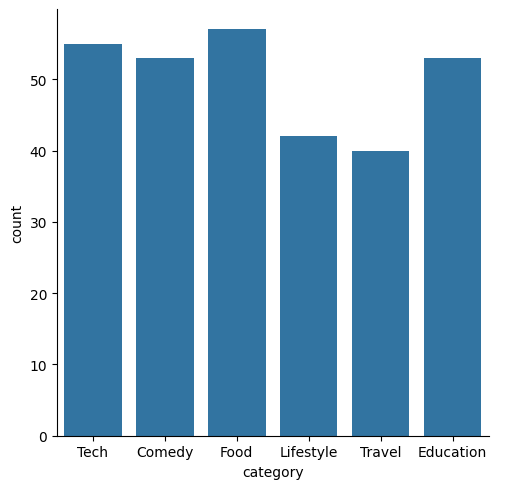

In [18]:
sns.catplot(x='category', data=df, kind='count');

Категории видео распределены нормально

### Тепловая карта корреляций (Correlation Heatmap)

Код строит тепловую карту линейных корреляций Пирсона между выбранными числовыми переменными.

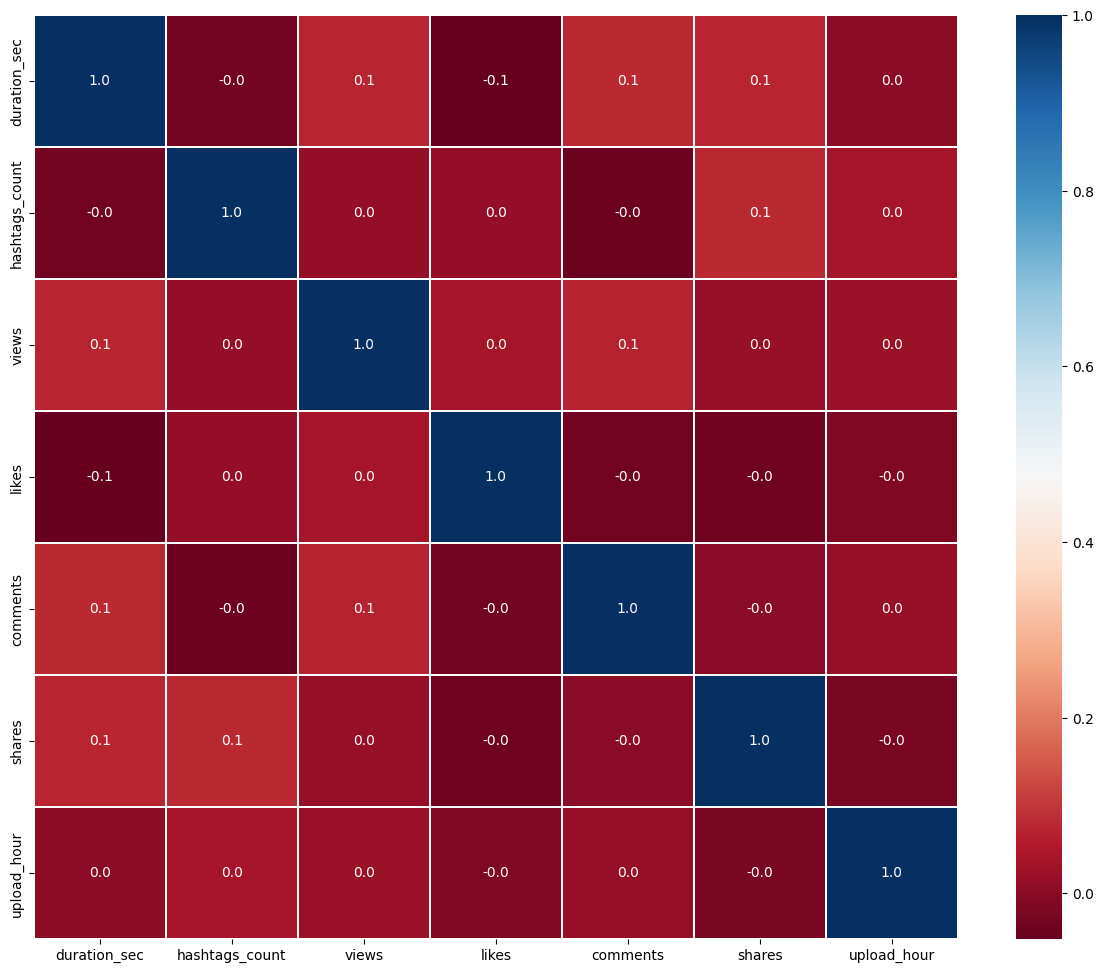

In [19]:
sns.heatmap(df[colnames].corr(method='pearson'), 
            square=True, annot=True, fmt=".1f", 
            linewidths=0.1, cmap="RdBu");

Все признаки практически не взаимодействуют между друг другом

### Сводная таблица среднего количества лайков

Код создаёт сводную таблицу (pivot table), показывающую **среднее количество лайков** в зависимости от часа публикации и категории видео.

In [20]:
df_pivot = df.pivot_table(index='upload_hour', columns='category', values='likes', aggfunc='mean')
df_pivot

category,Comedy,Education,Food,Lifestyle,Tech,Travel
upload_hour,,,,,,
0,39244.000000,30197.600000,NaN,47177.000000,8243.500000,NaN
1,24373.500000,15587.333333,37853.000000,14669.500000,24880.250000,14278.000000
2,34964.500000,17549.000000,13865.200000,3678.500000,6791.333333,1631.000000
3,34001.666667,31441.500000,NaN,16216.500000,13010.000000,21669.200000
4,40218.000000,39677.000000,24695.333333,5226.000000,46814.000000,NaN
5,25718.000000,27220.500000,17402.000000,27468.000000,24536.000000,19279.500000
6,31210.000000,29539.000000,27183.000000,38701.000000,16527.500000,12115.000000
7,20219.000000,23955.500000,27141.875000,NaN,28165.500000,NaN
8,14064.000000,6354.000000,47462.000000,31444.333333,14619.000000,25319.333333


На основе этой таблицы построим график соотношения среднего количества лайков распределенных по категориям в различные часы выкладки видео

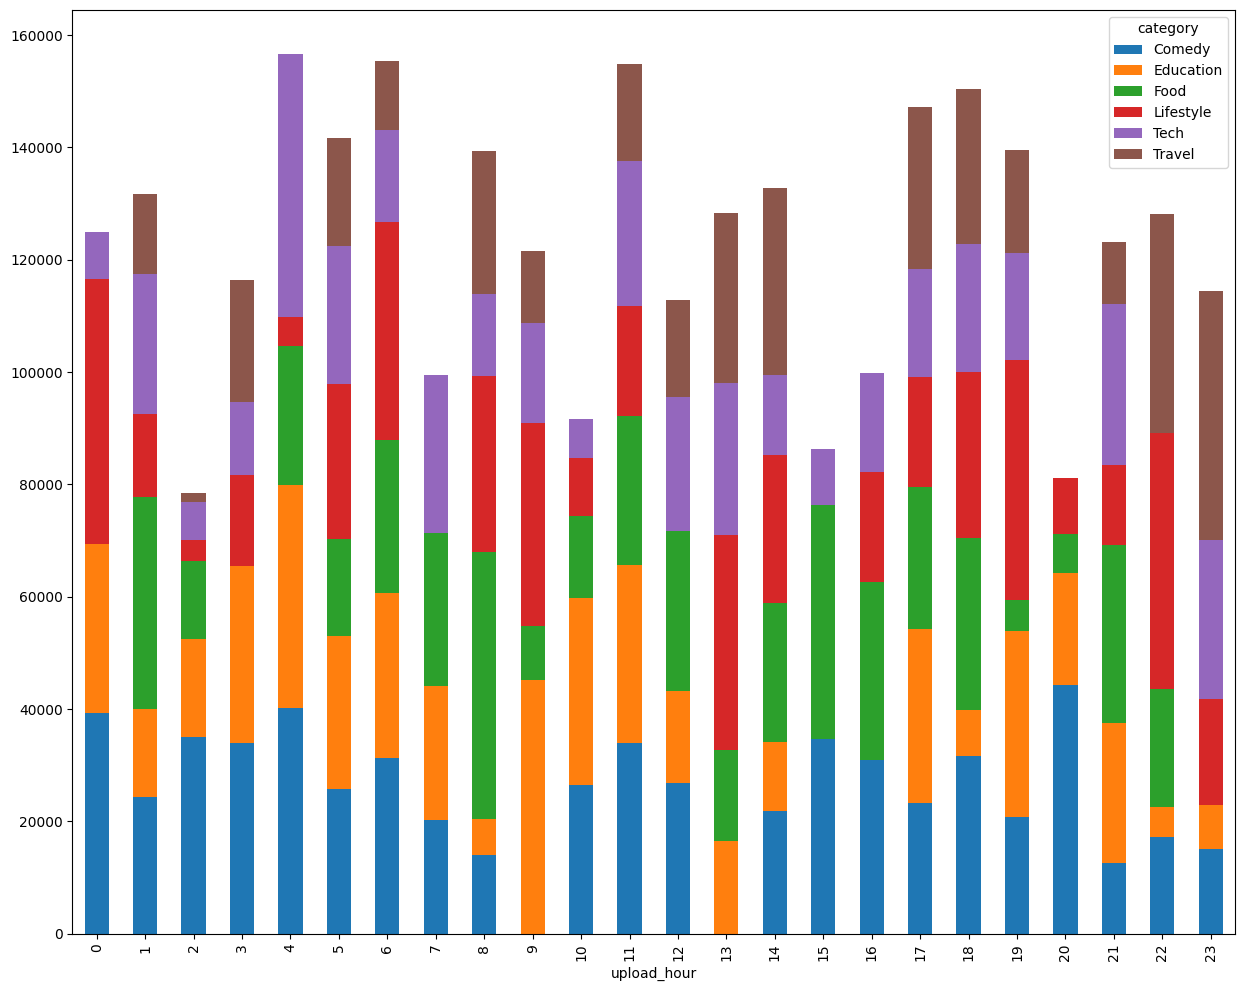

In [21]:
df_pivot.plot(kind='bar', stacked=True);

Stacked bar chart показывает, как распределяется среднее количество лайков по категориям видео в зависимости от часа публикации.

- Наибольшее среднее количество лайков приходится на **4, 5, 11, 17 и 18 часы**.
- Категория **Comedy** (синий цвет) стабильно вносит большой вклад в общее количество лайков почти во все часы.
- **Lifestyle** (красный) и **Travel** (коричневый) также показывают сильные результаты в пиковые часы.
- В утренние часы (особенно 6–9) общий уровень лайков заметно ниже.
- В поздние вечерние часы (после 21:00) снова наблюдается рост вовлеченности.

### Сводная таблица: Среднее количество лайков в зависимости от количества хэштегов

Код создаёт сводную таблицу, показывающую **среднее количество лайков** в разрезе количества использованных хэштегов и категории видео.

In [22]:
df_pivot = df.pivot_table(index='hashtags_count', columns='category', values='likes', aggfunc='mean')
df_pivot

category,Comedy,Education,Food,Lifestyle,Tech,Travel
hashtags_count,,,,,,
0,40326.000000,25573.571429,24729.111111,25211.400000,17854.750000,18622.000000
1,45759.000000,25066.833333,41147.000000,15934.000000,15543.666667,10695.000000
2,19991.333333,23239.333333,25380.200000,20690.333333,17985.800000,11878.571429
3,21270.250000,29690.500000,14495.000000,24182.250000,14751.400000,21651.333333
4,28193.333333,22962.200000,25114.600000,21050.750000,19531.400000,20655.666667
5,42163.600000,27796.666667,25999.500000,35458.000000,23547.166667,25419.000000
6,21367.500000,29696.500000,25508.833333,23847.333333,39723.000000,24074.000000
7,35971.400000,25627.333333,14641.000000,33333.000000,8617.250000,27194.000000
8,21916.200000,19386.333333,19217.000000,29387.000000,19905.285714,29408.500000


На основе этой таблицы построим график соотношения среднего количества лайков распределенных по категориям при разном количестве указанных хэштегов

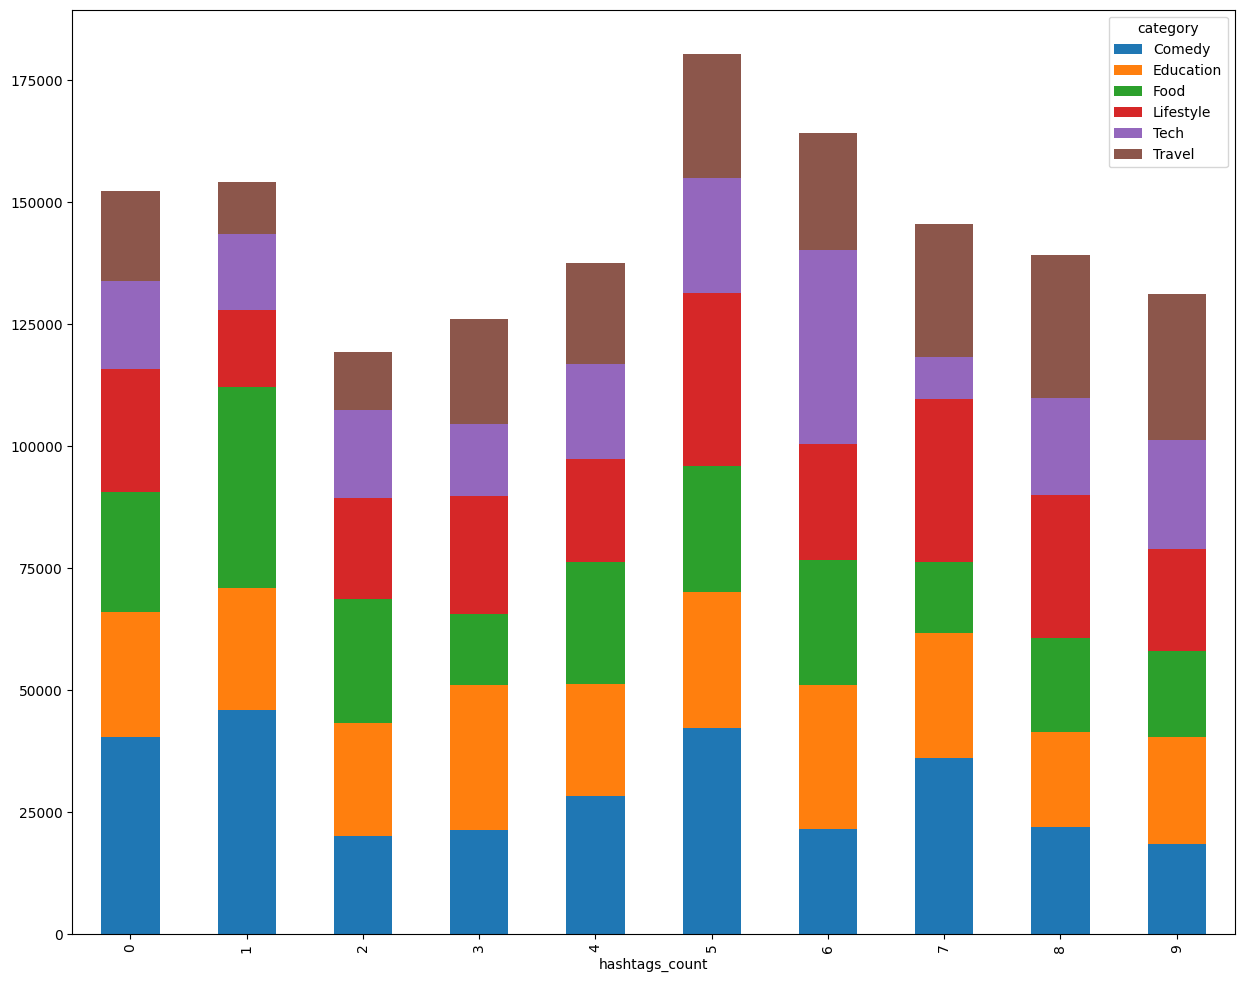

In [23]:
df_pivot.plot(kind='bar', stacked=True);


- Наибольшее среднее количество лайков достигается при **5 хэштегах**. Это явный пик на графике.
- Хорошие результаты также наблюдаются при **0–1** и **6 хэштегах**.
- При использовании **2–3 хэштегов** количество лайков заметно ниже.
- Категория **Comedy** (синий) стабильно показывает высокий вклад почти при любом количестве хэштегов.
- **Lifestyle** (красный) и **Travel** (коричневый) также активно участвуют в пиковых значениях.
- Категория **Tech** (фиолетовый) лучше всего работает при среднем и высоком количестве хэштегов (5–7).

# Гипотезы

Зафиксируем уровень значимости

In [24]:
alpha = 0.05 

## Гипотеза 1: активность днем больше

На основе раннее созданного признака `isDayTimeVideo` проверим гипотезу о том, что видео, которые мы выкладываем днем, набирают больше просмотров, чем видео, которые мы выкладываем в ночное время


### Формулировка гипотез

- **H₀**: Среднее количество просмотров у дневных и ночных видео **не отличается**.
- **H₁**: Среднее количество просмотров у дневных видео **выше**, чем у ночных (односторонняя альтернатива).

In [25]:
from scipy.stats import ttest_ind

day = df[df['isDayTimeVideo']==True]['views']
night= df[df['isDayTimeVideo']==False]['views']

t_stat, p_value = ttest_ind(day, night, equal_var=False)  # t-тест Уэлча

print("Значние t-статистики:", t_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Отвергаем нулевую гипотезу → Выборки статистически значимо отличаются.")
else:
    print("Нулевая гипотеза не отвергается → Статистически значимых различий нет.")

Значние t-статистики: 1.4213025873775
p-value: 0.1568290427810079
Нулевая гипотеза не отвергается → Статистически значимых различий нет.


### Результаты t-теста Уэлча

- **t-статистика**: 1.4213
- **p-value**: 0.1568

### Вывод

При уровне значимости α = 0.05 **нулевая гипотеза не отвергается** (p-value = 0.1568 > 0.05).

**Интерпретация:**  
Статистически значимых различий в среднем количестве просмотров между видео, опубликованными днём и ночью, **не обнаружено**. 

Таким образом, данные не подтверждают гипотезу о том, что дневные видео набирают существенно больше просмотров. Различия, наблюдаемые на визуализациях, не являются статистически значимыми и могут быть обусловлены случайными факторами.

## Гипотеза 2: категорией лайфстайл чаще делятся

Проверяем, действительно ли видео в категории **Lifestyle** получают больше репостов (shares), чем видео других категорий.

### Формулировка гипотез

- **H₀**: Распределение количества репостов у видео категории Lifestyle **не отличается** от других категорий.
- **H₁**: Распределение количества репостов у видео категории Lifestyle **отличается** от других категорий.

### Метод анализа

Так как распределение количества репостов обычно не является нормальным, был использован **U-тест Манна-Уитни** (непараметрический тест).

In [26]:
x = df[df['category']=='Lifestyle']['shares']
y = df[df['category']!='Lifestyle']['shares']

In [27]:
U, pval = stats.mannwhitneyu(x, y, alternative='two-sided')
print("Значние статистики Манна-Уитни:", U)
print("p-value:", pval)

if p_value < alpha:
    print("Отвергаем нулевую гипотезу → Выборки статистически значимо отличаются.")
else:
    print("Нулевая гипотеза не отвергается → Статистически значимых различий нет.")

Значние статистики Манна-Уитни: 5259.0
p-value: 0.7611119394145778
Нулевая гипотеза не отвергается → Статистически значимых различий нет.


### Результаты теста

- **Статистика U**: 5259.0
- **p-value**: 0.7611

### Вывод

При уровне значимости α = 0.05 **нулевая гипотеза не отвергается** (p-value = 0.7611 >> 0.05).

**Интерпретация:**  
Статистически значимых различий в количестве репостов между видео категории **Lifestyle** и видео других категорий **не обнаружено**. 

Данные не подтверждают гипотезу о том, что контент в категории Lifestyle делится чаще остальных. Уровень вовлеченности через репосты в этой категории находится на среднем уровне по сравнению с другими категориями.

## Гипотеза 3: количество хэштегов влияет на просмотры

Проверяем, влияет ли количество используемых хэштегов на количество просмотров видео.

### Формулировка гипотез

- **H₀**: Количество просмотров видео **не зависит** от количества хэштегов (группы с <5 и ≥5 хэштегами имеют одинаковое распределение).
- **H₁**: Количество просмотров видео **зависит** от количества хэштегов.

### Метод анализа

Так как распределение просмотров не является нормальным, был использован **U-тест Манна-Уитни**.

In [28]:
x = df[df['hashtags_count']<5]['views']
y = df[df['hashtags_count']>=5]['views']

In [29]:
U, pval = stats.mannwhitneyu(x, y, alternative='two-sided')
print("Значние статистики Манна-Уитни:", U)
print("p-value:", pval)

if p_value < 0.05:
    print("Отвергаем нулевую гипотезу → Выборки статистически значимо отличаются.")
else:
    print("Нулевая гипотеза не отвергается → Статистически значимых различий нет.")

Значние статистики Манна-Уитни: 11345.0
p-value: 0.8109739277924934
Нулевая гипотеза не отвергается → Статистически значимых различий нет.


### Результаты теста

- **Статистика U**: 11345.0
- **p-value**: 0.8110

### Вывод

При уровне значимости α = 0.05 **нулевая гипотеза не отвергается** (p-value = 0.8110 > 0.05).

**Интерпретация:**  
Статистически значимого влияния количества хэштегов на количество просмотров **не обнаружено**. 

Различия в просмотрах между видео с малым (< 5) и большим (≥ 5) количеством хэштегов носят случайный характер. Простое увеличение или уменьшение числа хэштегов само по себе не приводит к значимому росту охвата.

### Рекомендация

Качество и релевантность хэштегов важнее их количества. Рекомендуется использовать 3–7 хорошо подобранных хэштегов, соответствующих теме видео и популярным поисковым запросам.

# Машинное обучение

Импортируем необходимые библиотеки для работы

In [30]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import MinMaxScaler

## Новые признаки

### Уровень вовлеченности

Из трех переменных, которые показывают взаимодействие пользователя с видео (`likes`, `comments`, `shares`), и показателя просмотров, создадим новый признак уровня вовлеченности, который будет расчитываться по формуле:

$$ 
\text{engagement rate}= \frac{\text{likes} + \text{comments} + \text{shares}}{\text{views}}
$$

In [31]:
df['engagement_rate'] = (df['likes']+df['comments']+df['shares'])/df['views']

### Категория длительности

Разобьем наш признак отвечающий за длительность видео на категории с коробками от 0 до 15, от 15 до 30, от 30 до 45, от 45 до 60, соответственно с флагами (0, 1, 2, 3) 

In [32]:
df["duration_category"] = pd.cut(df["duration_sec"], bins=[0,15,30,45,60], labels = [0,1,2,3])

Посмотрим, что получилось

In [33]:
df[['duration_sec', 'duration_category']]

,duration_sec,duration_category
0,43,2
1,56,3
2,33,2
3,19,1
4,47,3
...,...,...
295,15,0
296,32,2
297,29,1
298,54,3


### OHE для `category` 

Разобьем наш изначальный категориальный признак `category` при помощи функции `get_dummies` на новые признаки

In [34]:
df = pd.get_dummies(df,columns=["category"], drop_first=True,dtype=int)
df.head()

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,isDayTimeVideo,engagement_rate,duration_category,category_Education,category_Food,category_Lifestyle,category_Tech,category_Travel
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,False,0.128593,2,0,0,0,1,0
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,True,0.088601,3,0,0,0,0,0
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,False,0.159258,2,0,1,0,0,0
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,False,0.359913,1,0,0,1,0,0
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,False,0.132639,3,0,0,0,1,0


## Данные для моделей

Подготовим наши данные для обучения моделей

Для начала избавимся от неинформативных признаков `video_id` и `title`

In [35]:
df.drop(['video_id', 'title'], inplace=True, axis=1)

Также выделим необходимый признаки в новую таблицу

In [36]:
df_ml = df.drop(['duration_sec', 'isDayTimeVideo'], axis=1)
df_ml

,hashtags_count,views,likes,comments,shares,upload_hour,engagement_rate,duration_category,category_Education,category_Food,category_Lifestyle,category_Tech,category_Travel
0,9,198775,21933,3228,400,8,0.128593,2,0,0,0,1,0
1,2,290336,20063,3719,1942,16,0.088601,3,0,0,0,0,0
2,6,264206,37032,3228,1817,7,0.159258,2,0,1,0,0,0
3,9,85076,27269,2371,980,1,0.359913,1,0,0,1,0,0
4,8,90780,8041,2891,1109,23,0.132639,3,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3,248940,23810,488,1247,12,0.102615,0,0,0,0,1,0
296,4,366340,29586,46,1548,8,0.085112,2,0,0,0,0,1
297,3,434027,6471,3359,1069,21,0.025111,1,0,0,0,0,0
298,4,318623,6459,4873,1690,14,0.040870,3,0,1,0,0,0


### Нормализация данных

Поскольку значения столбцов очень сильно разнятся нам необходимо нормализовать данные

При помощи функции `MinMaxScaler()` приведем столбцы `hashtags_count`, `upload_hour` к диапозону значений [0, 1]

In [37]:
scaler = MinMaxScaler()
col2scale = ['hashtags_count', 'views','likes','comments','shares', 'upload_hour']
df_2scale = df_ml[col2scale]

scaler.fit_transform(df_2scale)
df_ml[col2scale] = df_2scale

## Модели

### Обучающая и тестовая выборки

При помощи функции `train_test_split` разобьем наши признаки и целевую переменную на обучающую и тестовую выборки в соотношении 80на20

In [38]:
X = df_ml.drop('engagement_rate', axis=1)
y = df_ml['engagement_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Линейная регрессия

Для предсказания целевой переменной была обучена модель **Линейной регрессии** помощи функции `LinearRegression()` из библиотеки `scikit-learn`

In [39]:
lr = LinearRegression()
lr.fit(X_train, y_train)
preds_lr = lr.predict(X_test)

print('RMSE:', np.sqrt(mean_squared_error(y_test, preds_lr)))
print('R2:', r2_score(y_test, preds_lr))

RMSE: 2.766378714347661
R2: 0.06740247436426039


#### Результаты на тестовой выборке

- **RMSE**: 2.7664
- **R²**: 0.0674

#### Интерпретация

Модель **Линейной регрессии** показывает очень слабое качество предсказания:

- Коэффициент детерминации **R² = 0.0674** означает, что модель объясняет всего лишь **6.74%** дисперсии целевой переменной. Это крайне низкий результат.
- RMSE ≈ 2.77 говорит о том, что в среднем предсказания модели отклоняются от реальных значений примерно на 2.77 единицы.


Линейная регрессия демонстрирует слабую прогностическую способность на данных. Линейные зависимости между признаками и целевой переменной выражены слабо. 

### Random Forest Regressor

Была обучена модель **Случайного леса** — один из наиболее мощных алгоритмов машинного обучения для задач регрессии.

In [40]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

print('RMSE:', np.sqrt(mean_squared_error(y_test, preds_rf)))
print('R2:', r2_score(y_test, preds_rf))

RMSE: 1.3553311154277912
R2: 0.7761475726516868


#### Результаты на тестовой выборке

- **RMSE**: 1.3740
- **R²**: 0.7699

#### Интерпретация

Модель **Random Forest** показала значительно лучшее качество по сравнению с линейной регрессией:

- **R² = 0.7699** — модель объясняет **76.99%** дисперсии целевой переменной. Это хороший результат для большинства практических задач.
- **RMSE ≈ 1.374** — средняя ошибка предсказания составляет около 1.37 единиц, что существенно ниже, чем у линейной регрессии.

Модель Random Forest демонстрирует **хорошую прогностическую способность**. Она хорошо улавливает нелинейные зависимости в данных и может быть использована для предсказания целевой переменной. 

#### Анализ важности признаков (Feature Importance)

После обучения модели Random Forest был проведён анализ важности признаков. 

               Feature  Importance
1                views    0.926314
2                likes    0.028720
4               shares    0.017501
3             comments    0.011373
6    duration_category    0.005100
5          upload_hour    0.003881
8        category_Food    0.002290
0       hashtags_count    0.002027
10       category_Tech    0.000952
11     category_Travel    0.000693
9   category_Lifestyle    0.000575
7   category_Education    0.000574


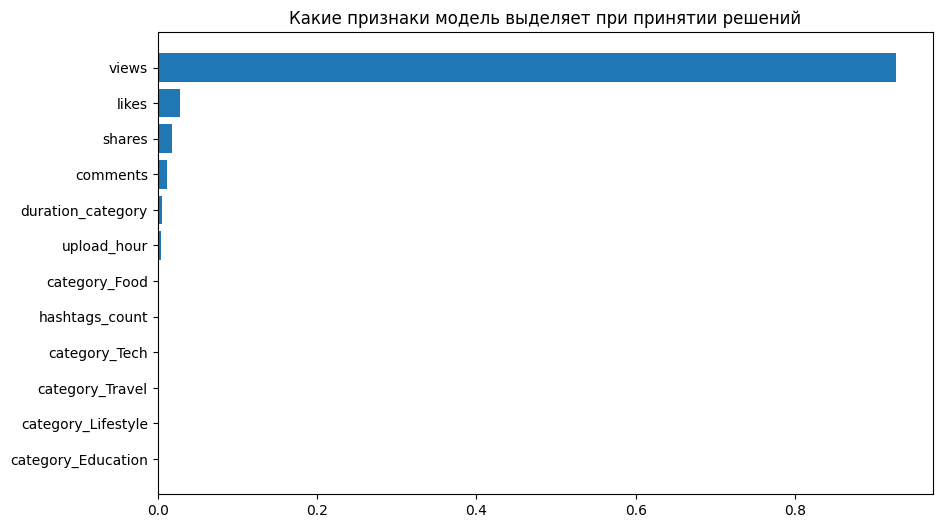

In [41]:
importances = rf.feature_importances_
feature_names = X.columns 

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print(feature_imp_df)

# Draw graph
plt.figure(figsize=(10,6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Какие признаки модель выделяет при принятии решений")
plt.show()

На графике видно, что модель очень сильно опирается на `views`

Так что если убрать этот признак из данных -> качество сильно упадет

In [42]:
df_ml_rf = df_ml.copy()
df_ml_rf.drop("views",axis=1,inplace = True)

Повторим обучение модели случайного леса, но уже без столбца просмотров

In [43]:
X = df_ml_rf.drop('engagement_rate', axis=1)
y = df_ml_rf['engagement_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

print('RMSE:', np.sqrt(mean_squared_error(y_test, preds_rf)))
print('R2:', r2_score(y_test, preds_rf))

RMSE: 2.9295654628875205
R2: -0.04586927398658136


Модель полность сломалась и метрика r2 выдала отрицательное значение

## Gradient Boosting Regressor

Была обучена модель **Gradient Boosting** — один из самых мощных алгоритмов градиентного бустинга.


In [44]:
X = df_ml.drop(['engagement_rate'], axis=1)
y = df_ml['engagement_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
preds_gb = gb.predict(X_test)

print('RMSE:', np.sqrt(mean_squared_error(y_test, preds_gb)))
print('R2:', r2_score(y_test, preds_gb))

RMSE: 1.283172503756947
R2: 0.7993491148513518



#### Результаты на тестовой выборке

- **RMSE**: 1.2879
- **R²**: 0.7979

#### Интерпретация

Модель **Gradient Boosting** показала наилучшее качество среди рассмотренных моделей:

- **R² = 0.7979** — модель объясняет **79.79%** дисперсии целевой переменной (`engagement_rate`). Это хороший результат.
- **RMSE ≈ 1.288** — средняя ошибка предсказания составляет около 1.29 единиц.

Gradient Boosting продемонстрировал **лучшую прогностическую способность** по сравнению с Linear Regression и Random Forest. Модель хорошо улавливает сложные нелинейные зависимости в данных и может быть рекомендована для предсказания коэффициента вовлеченности.


#### Анализ важности признаков

Приэтом если посмотрим на важность признаков у градиентного бустинга будет та же проблема, что и у случайного леса

Модель слишком сильно опирается на столбец просмотров

               Feature    Importance
1                views  9.611975e-01
2                likes  2.898771e-02
11     category_Travel  2.570078e-03
3             comments  2.078918e-03
4               shares  2.051831e-03
0       hashtags_count  1.115335e-03
5          upload_hour  9.752203e-04
6    duration_category  6.038836e-04
10       category_Tech  4.093800e-04
9   category_Lifestyle  5.732196e-06
7   category_Education  4.150636e-06
8        category_Food  2.690534e-07


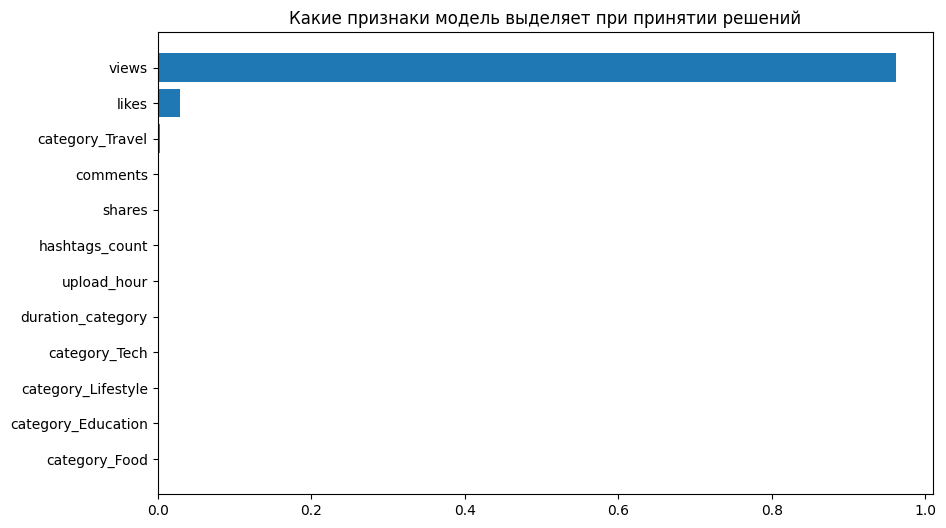

In [45]:
importances = gb.feature_importances_
feature_names = X.columns 

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print(feature_imp_df)

# Draw graph
plt.figure(figsize=(10,6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Какие признаки модель выделяет при принятии решений")
plt.show()